# Eksperimen: Earthquake Significance Prediction
**Nama**: Ninditya  
**Dataset**: USGS Earthquake Data (2022)  
**Task**: Binary Classification — predict whether an earthquake will be significant (magnitude ≥ 5.0)

---

## 0. Import Libraries

In [4]:
import os
import io
import requests
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

pd.set_option('display.max_columns', 30)
pd.set_option('display.float_format', '{:.4f}'.format)
print('Libraries imported successfully')

Libraries imported successfully


---
## 1. Data Loading

We use the **USGS Earthquake Hazards Program** public REST API to download earthquake records for 2022 with magnitude ≥ 2.0.

In [5]:
USGS_URL = (
    "https://earthquake.usgs.gov/fdsnws/event/1/query?"
    "format=csv&starttime=2022-01-01&endtime=2022-12-31"
    "&minmagnitude=2.5&limit=10000&orderby=time"
)

RAW_FILE = '../earthquake_raw.csv'

if not os.path.exists(RAW_FILE):
    print('Downloading earthquake data from USGS …')
    response = requests.get(USGS_URL, timeout=120)
    response.raise_for_status()
    df_raw = pd.read_csv(io.StringIO(response.text))
    df_raw.to_csv(RAW_FILE, index=False)
    print(f'Downloaded {len(df_raw):,} records.')
else:
    df_raw = pd.read_csv(RAW_FILE)
    print(f'Loaded {len(df_raw):,} records from cache.')

df = df_raw.copy()
print('\nColumns:', df.columns.tolist())

Downloaded 10,000 records.

Columns: ['time', 'latitude', 'longitude', 'depth', 'mag', 'magType', 'nst', 'gap', 'dmin', 'rms', 'net', 'id', 'updated', 'place', 'type', 'horizontalError', 'depthError', 'magError', 'magNst', 'status', 'locationSource', 'magSource']


In [6]:
print('Shape:', df.shape)
df.head(5)

Shape: (10000, 22)


,time,latitude,longitude,depth,mag,magType,nst,gap,dmin,rms,net,id,updated,place,type,horizontalError,depthError,magError,magNst,status,locationSource,magSource
0,2022-12-30T23:52:34.913Z,34.6296,24.8996,10.0000,4.0000,mb,68.0000,124.0000,0.6570,0.5400,us,us7000j15e,2023-03-07T19:00:00.040Z,"46 km S of Moíres, Greece",earthquake,4.6800,1.9250,0.1110,22.0000,reviewed,us,us
1,2022-12-30T23:31:14.883Z,-6.0376,146.1063,60.3580,4.1000,mb,19.0000,77.0000,3.5040,0.5700,us,us7000j3pf,2023-03-07T19:00:10.040Z,"38 km NE of Kainantu, Papua New Guinea",earthquake,12.3100,5.5630,0.1850,8.0000,reviewed,us,us
2,2022-12-30T23:15:14.479Z,-33.6877,57.5022,10.0000,4.6000,mb,28.0000,96.0000,12.5660,0.6000,us,us7000j3pe,2023-03-07T19:00:10.040Z,Southwest Indian Ridge,earthquake,7.0600,1.8710,0.1580,12.0000,reviewed,us,us
3,2022-12-30T23:14:37.589Z,-0.1974,97.3179,10.0000,4.4000,mb,38.0000,91.0000,1.5130,0.6900,us,us7000j15a,2023-03-07T19:00:00.040Z,"269 km SW of Sibolga, Indonesia",earthquake,6.7400,1.8640,0.1270,18.0000,reviewed,us,us
4,2022-12-30T22:55:16.050Z,18.0732,-67.0983,18.3900,3.0300,md,20.0000,122.0000,0.0480,0.2200,pr,pr71389923,2022-12-31T03:47:25.775Z,"1 km SSE of Monte Grande, Puerto Rico",earthquake,0.5000,0.3100,0.1663,12.0000,reviewed,pr,pr


---
## 2. Exploratory Data Analysis (EDA)
### 2.1 Basic Information

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 22 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   time             10000 non-null  object 
 1   latitude         10000 non-null  float64
 2   longitude        10000 non-null  float64
 3   depth            10000 non-null  float64
 4   mag              10000 non-null  float64
 5   magType          10000 non-null  object 
 6   nst              9377 non-null   float64
 7   gap              9377 non-null   float64
 8   dmin             8767 non-null   float64
 9   rms              10000 non-null  float64
 10  net              10000 non-null  object 
 11  id               10000 non-null  object 
 12  updated          10000 non-null  object 
 13  place            10000 non-null  object 
 14  type             10000 non-null  object 
 15  horizontalError  9279 non-null   float64
 16  depthError       10000 non-null  float64
 17  magError     

In [8]:
df.describe()

,latitude,longitude,depth,mag,nst,gap,dmin,rms,horizontalError,depthError,magError,magNst
count,10000.0000,10000.0000,10000.0000,10000.0000,9377.0000,9377.0000,8767.0000,10000.0000,9279.0000,10000.0000,9276.0000,9314.0000
mean,18.3810,-35.4465,62.8590,3.8482,39.1894,130.0449,2.9631,0.5221,6.5854,4.4075,0.1309,31.0403
std,30.9852,124.9435,113.9029,0.8642,35.2953,73.2038,4.7757,0.2667,4.2233,4.7633,0.1000,47.8019
min,-65.3668,-179.9976,-3.7400,2.5000,3.0000,12.0000,0.0000,0.0000,0.0800,0.0000,0.0000,0.0000
25%,-7.0957,-155.4157,10.0000,2.9700,18.0000,72.0000,0.4549,0.3200,3.4100,1.7748,0.0830,9.0000
50%,19.2262,-67.7640,16.5260,4.2000,27.0000,112.0000,1.3690,0.5300,6.5600,2.0070,0.1180,16.0000
75%,48.0697,113.7158,59.3000,4.5000,49.0000,183.0000,3.2725,0.7000,9.4300,6.5615,0.1630,33.0000
max,85.8088,179.9854,660.0000,7.6000,452.0000,352.0000,52.9190,1.8100,41.3000,38.7000,3.9400,760.0000


### 2.2 Missing Value Analysis

                 Missing Count  Missing %
dmin                      1233    12.3300
magError                   724     7.2400
horizontalError            721     7.2100
magNst                     686     6.8600
nst                        623     6.2300
gap                        623     6.2300


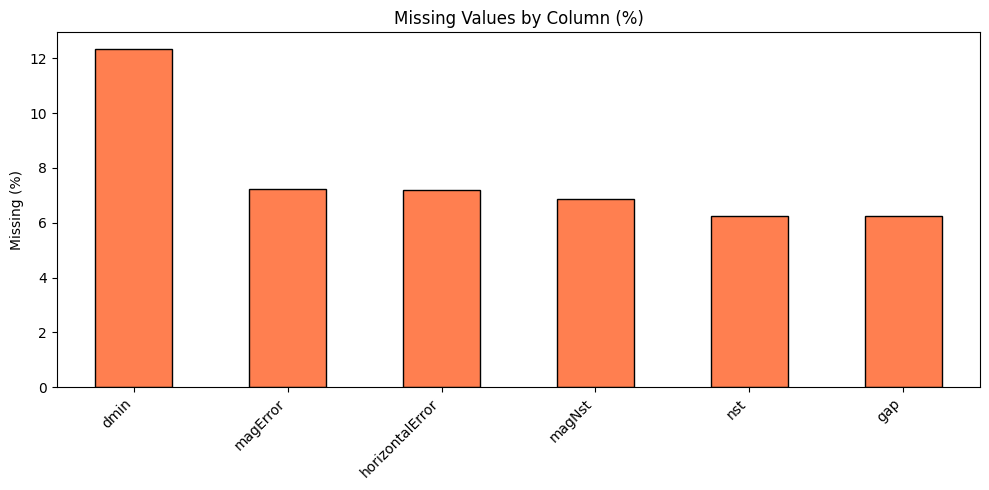

In [9]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing %', ascending=False)
print(missing_df)

plt.figure(figsize=(10, 5))
missing_df['Missing %'].plot(kind='bar', color='coral', edgecolor='black')
plt.title('Missing Values by Column (%)')
plt.ylabel('Missing (%)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### 2.3 Target Variable Distribution

We define **significant = 1** when magnitude ≥ 5.0, and **0** otherwise.

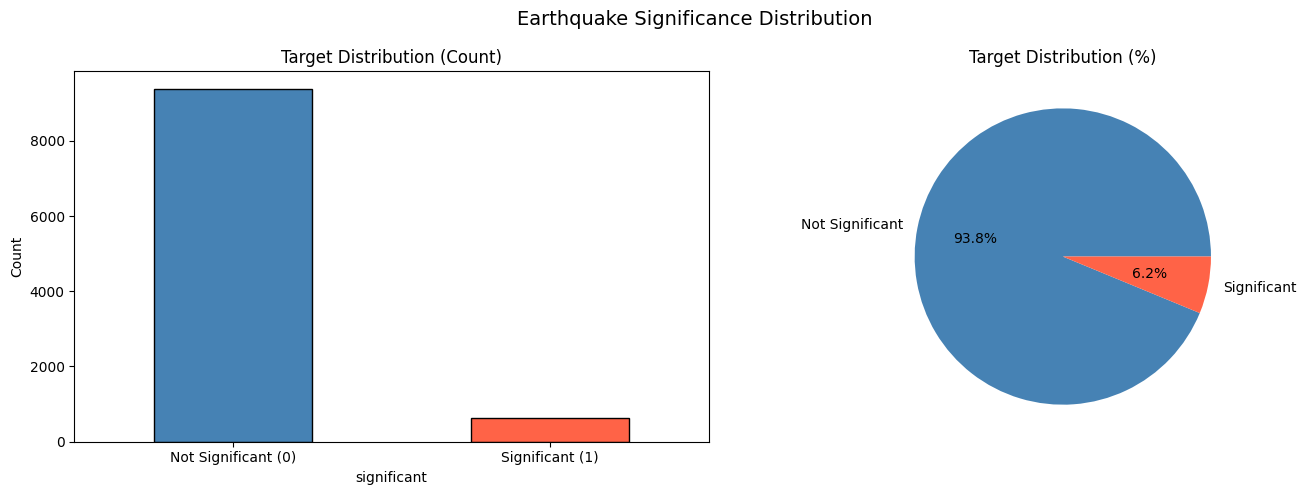

significant
0    9377
1     623
Name: count, dtype: int64


In [10]:
df['significant'] = (df['mag'] >= 5.0).astype(int)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df['significant'].value_counts().plot(
    kind='bar', ax=axes[0], color=['steelblue', 'tomato'], edgecolor='black'
)
axes[0].set_title('Target Distribution (Count)')
axes[0].set_xticklabels(['Not Significant (0)', 'Significant (1)'], rotation=0)
axes[0].set_ylabel('Count')

df['significant'].value_counts(normalize=True).plot(
    kind='pie', ax=axes[1], labels=['Not Significant', 'Significant'],
    autopct='%1.1f%%', colors=['steelblue', 'tomato']
)
axes[1].set_title('Target Distribution (%)')
axes[1].set_ylabel('')

plt.suptitle('Earthquake Significance Distribution', fontsize=14)
plt.tight_layout()
plt.show()

print(df['significant'].value_counts())

### 2.4 Magnitude Distribution

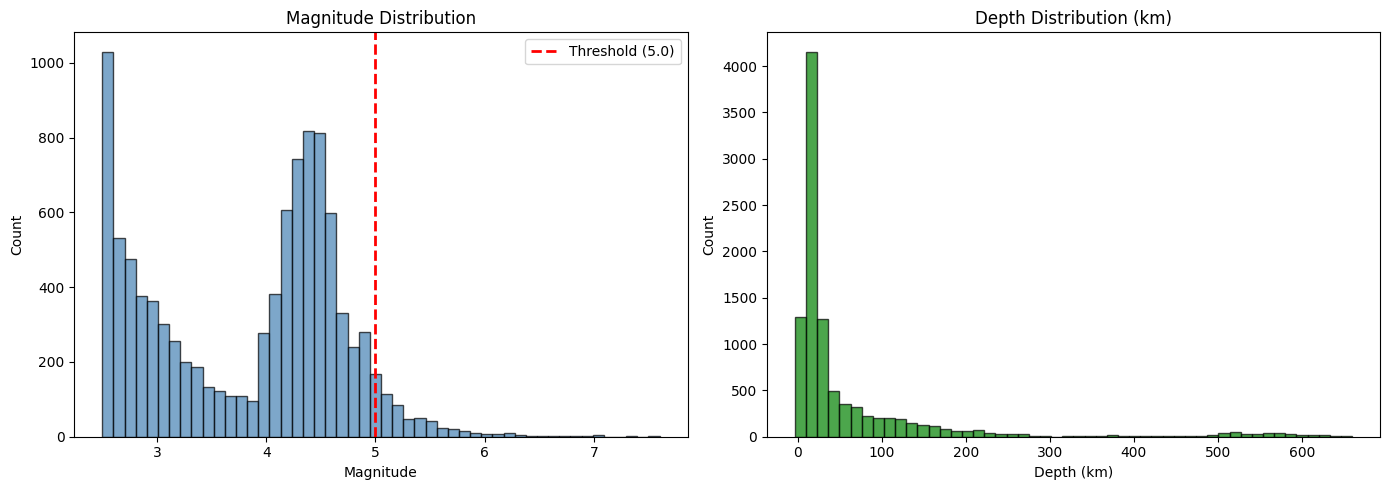

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['mag'], bins=50, color='steelblue', edgecolor='black', alpha=0.7)
axes[0].axvline(x=5.0, color='red', linestyle='--', linewidth=2, label='Threshold (5.0)')
axes[0].set_title('Magnitude Distribution')
axes[0].set_xlabel('Magnitude')
axes[0].set_ylabel('Count')
axes[0].legend()

axes[1].hist(df['depth'], bins=50, color='green', edgecolor='black', alpha=0.7)
axes[1].set_title('Depth Distribution (km)')
axes[1].set_xlabel('Depth (km)')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

### 2.5 Feature Distributions

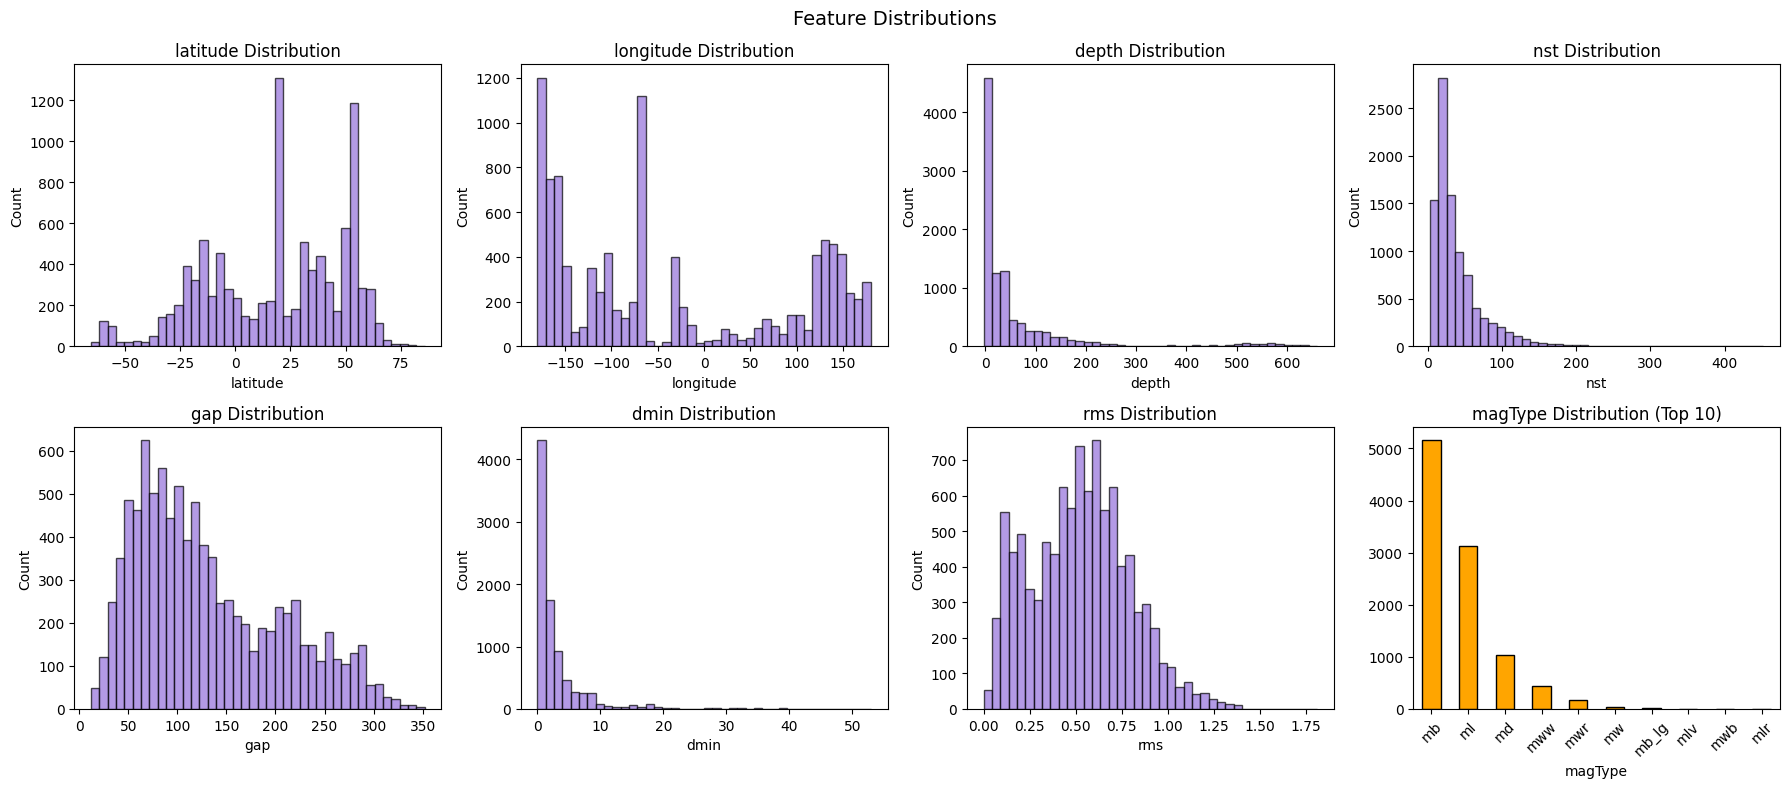

In [12]:
numeric_features = ['latitude', 'longitude', 'depth', 'nst', 'gap', 'dmin', 'rms']
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, col in enumerate(numeric_features):
    if col in df.columns:
        axes[i].hist(df[col].dropna(), bins=40, color='mediumpurple', edgecolor='black', alpha=0.7)
        axes[i].set_title(f'{col} Distribution')
        axes[i].set_xlabel(col)
        axes[i].set_ylabel('Count')

# magType distribution
df['magType'].value_counts().head(10).plot(kind='bar', ax=axes[7], color='orange', edgecolor='black')
axes[7].set_title('magType Distribution (Top 10)')
axes[7].set_xlabel('magType')
axes[7].tick_params(axis='x', rotation=45)

plt.suptitle('Feature Distributions', fontsize=14)
plt.tight_layout()
plt.show()

### 2.6 Correlation Analysis

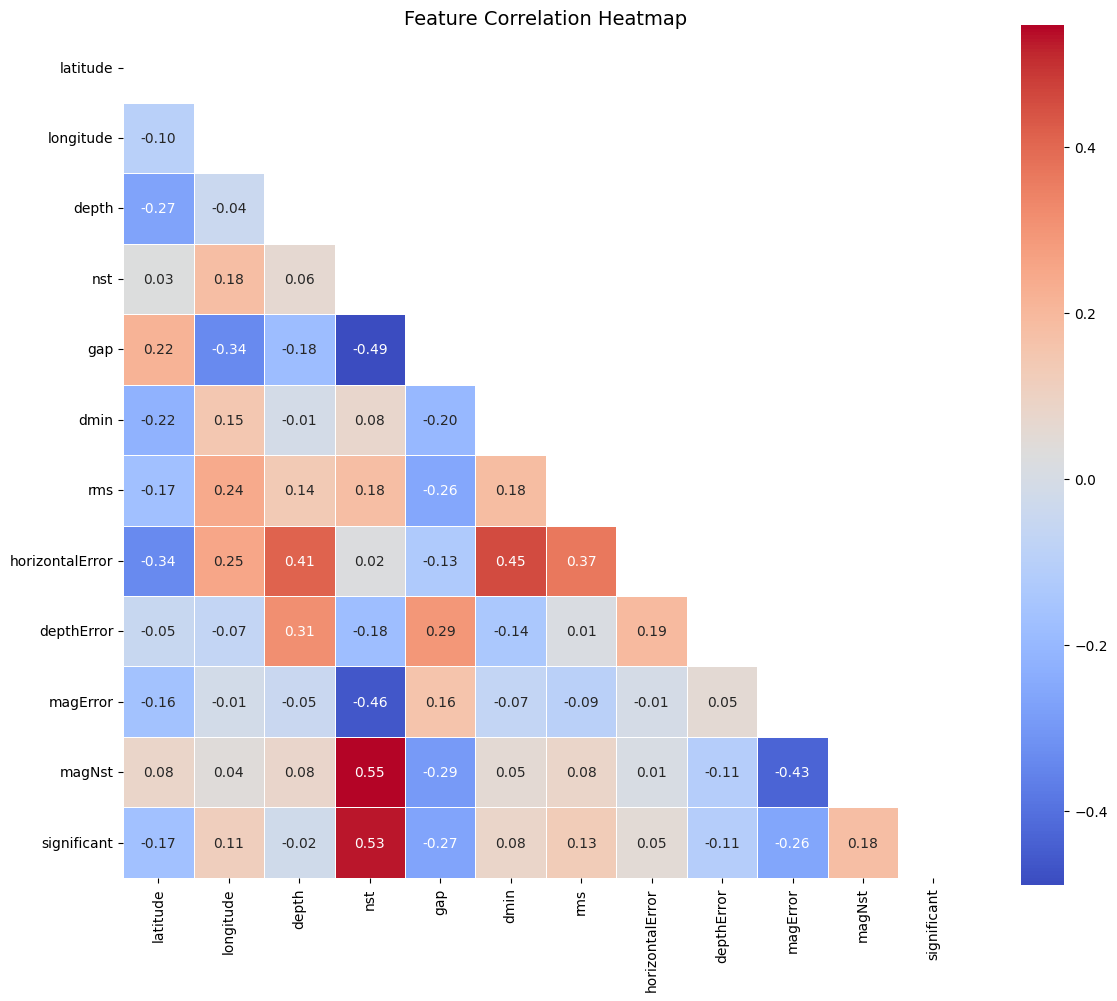

In [13]:
corr_cols = ['latitude', 'longitude', 'depth', 'nst', 'gap', 'dmin', 'rms',
             'horizontalError', 'depthError', 'magError', 'magNst', 'significant']
corr_df = df[corr_cols].dropna()

plt.figure(figsize=(12, 10))
mask = np.triu(np.ones_like(corr_df.corr(), dtype=bool))
sns.heatmap(
    corr_df.corr(), annot=True, fmt='.2f', cmap='coolwarm',
    mask=mask, square=True, linewidths=0.5
)
plt.title('Feature Correlation Heatmap', fontsize=14)
plt.tight_layout()
plt.show()

### 2.7 Geographic Distribution of Earthquakes

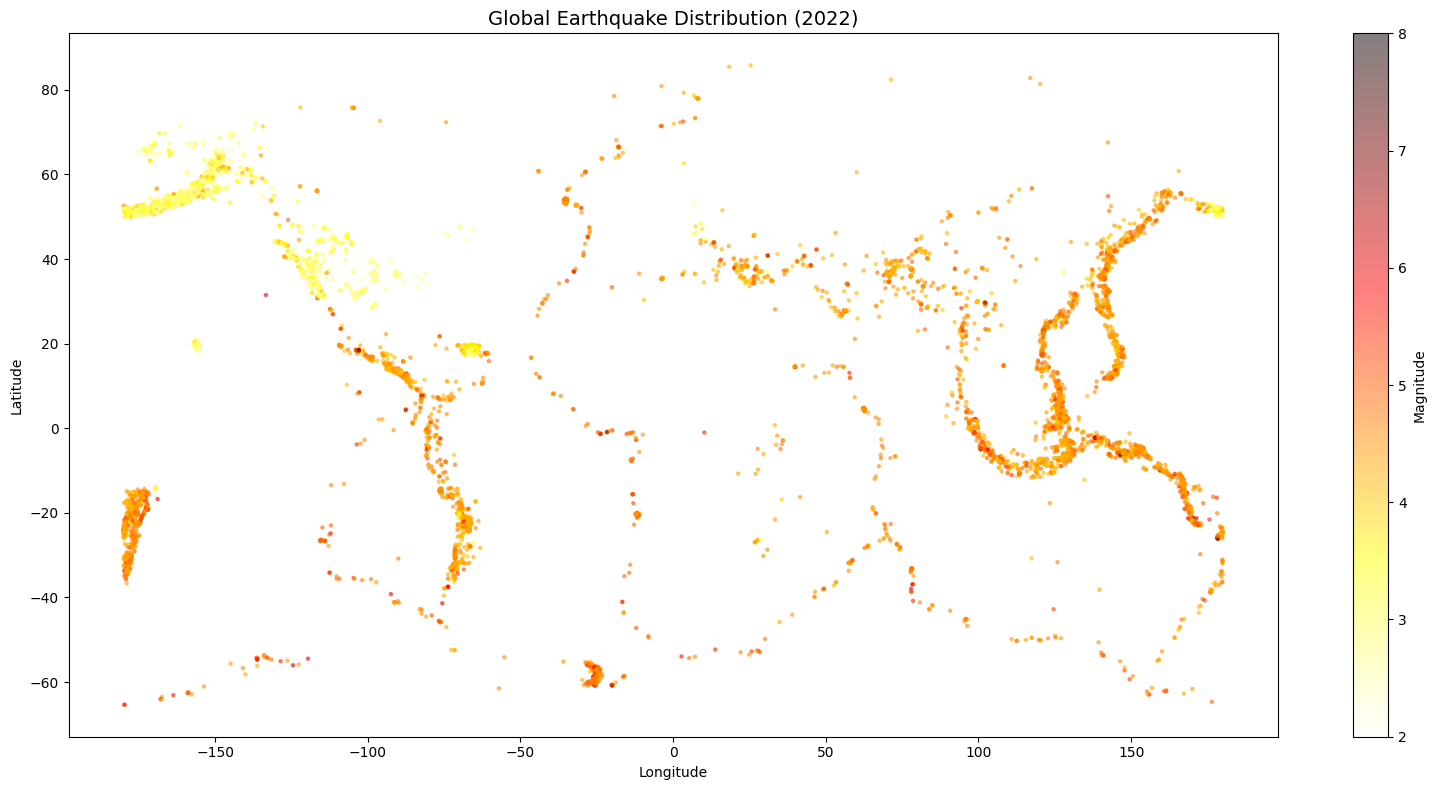

In [14]:
plt.figure(figsize=(16, 8))
scatter = plt.scatter(
    df['longitude'], df['latitude'],
    c=df['mag'], cmap='hot_r', s=5, alpha=0.5, vmin=2, vmax=8
)
plt.colorbar(scatter, label='Magnitude')
plt.title('Global Earthquake Distribution (2022)', fontsize=14)
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.tight_layout()
plt.show()

### 2.8 Depth vs Magnitude

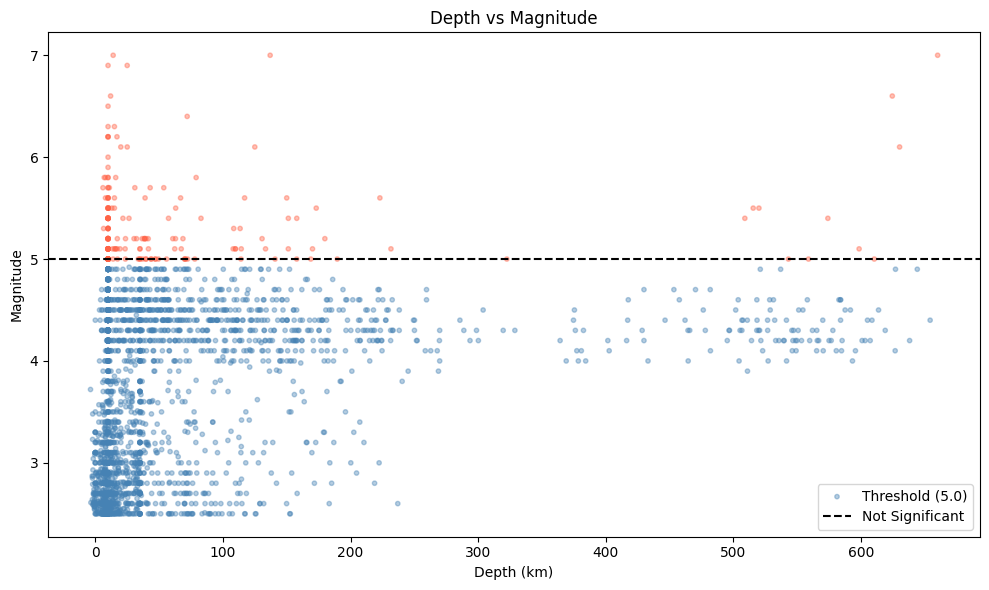

In [15]:
sample = df.sample(min(3000, len(df)), random_state=42)

plt.figure(figsize=(10, 6))
colors = sample['significant'].map({0: 'steelblue', 1: 'tomato'})
plt.scatter(sample['depth'], sample['mag'], c=colors, alpha=0.4, s=10)
plt.axhline(y=5.0, color='black', linestyle='--', linewidth=1.5, label='Threshold 5.0')
plt.title('Depth vs Magnitude')
plt.xlabel('Depth (km)')
plt.ylabel('Magnitude')
plt.legend(['Threshold (5.0)', 'Not Significant', 'Significant'])
plt.tight_layout()
plt.show()

---
## 3. Data Preprocessing
### 3.1 Select Features and Create Target

In [16]:
FEATURE_COLS = [
    'latitude', 'longitude', 'depth', 'magType',
    'nst', 'gap', 'dmin', 'rms',
    'horizontalError', 'depthError', 'magError', 'magNst',
]

df_clean = df[FEATURE_COLS + ['significant']].copy()
print(f'Shape after feature selection: {df_clean.shape}')
print(f'Missing values:\n{df_clean.isnull().sum()}')

Shape after feature selection: (10000, 13)
Missing values:
latitude              0
longitude             0
depth                 0
magType               0
nst                 623
gap                 623
dmin               1233
rms                   0
horizontalError     721
depthError            0
magError            724
magNst              686
significant           0
dtype: int64


### 3.2 Handle Missing Values

In [17]:
numeric_cols = [
    'latitude', 'longitude', 'depth',
    'nst', 'gap', 'dmin', 'rms',
    'horizontalError', 'depthError', 'magError', 'magNst',
]

for col in numeric_cols:
    median_val = df_clean[col].median()
    df_clean[col] = df_clean[col].fillna(median_val)

df_clean['magType'] = df_clean['magType'].fillna('unknown').astype(str).str.strip().str.lower()

print('Missing values after imputation:')
print(df_clean.isnull().sum())

Missing values after imputation:
latitude           0
longitude          0
depth              0
magType            0
nst                0
gap                0
dmin               0
rms                0
horizontalError    0
depthError         0
magError           0
magNst             0
significant        0
dtype: int64


### 3.3 Encode Categorical Feature (magType)

In [18]:
le = LabelEncoder()
df_clean['magType'] = le.fit_transform(df_clean['magType'])

print('magType encoding:')
for label, encoded in zip(le.classes_, le.transform(le.classes_)):
    print(f'  {label} → {encoded}')

magType encoding:
  mb → 0
  mb_lg → 1
  md → 2
  ml → 3
  mlr → 4
  mlv → 5
  mw → 6
  mwb → 7
  mwr → 8
  mww → 9


### 3.4 Feature Scaling (StandardScaler)

In [19]:
X = df_clean[FEATURE_COLS]
y = df_clean['significant']

scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=FEATURE_COLS, index=X.index)

print('Before scaling (latitude):')
print(f'  mean={X["latitude"].mean():.3f}  std={X["latitude"].std():.3f}')
print('After scaling (latitude):')
print(f'  mean={X_scaled["latitude"].mean():.3f}  std={X_scaled["latitude"].std():.3f}')

Before scaling (latitude):
  mean=18.381  std=30.985
After scaling (latitude):
  mean=0.000  std=1.000


### 3.5 Train-Test Split

In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Train size: {X_train.shape[0]:,}  ({X_train.shape[0]/len(X_scaled)*100:.1f}%)')
print(f'Test size : {X_test.shape[0]:,}  ({X_test.shape[0]/len(X_scaled)*100:.1f}%)')
print(f'Train class balance: {y_train.value_counts(normalize=True).to_dict()}')

Train size: 8,000  (80.0%)
Test size : 2,000  (20.0%)
Train class balance: {0: 0.93775, 1: 0.06225}


---
## 4. Save Preprocessed Data

In [21]:
OUTPUT_DIR = 'earthquake_preprocessing'
OUTPUT_FILE = os.path.join(OUTPUT_DIR, 'earthquake_preprocessing.csv')

os.makedirs(OUTPUT_DIR, exist_ok=True)

result = pd.concat([X_scaled, y.reset_index(drop=True)], axis=1)
result.to_csv(OUTPUT_FILE, index=False)

print(f'Preprocessed data saved → {OUTPUT_FILE}')
print(f'Shape: {result.shape}')
result.head()

Preprocessed data saved → earthquake_preprocessing/earthquake_preprocessing.csv
Shape: (10000, 13)


,latitude,longitude,depth,magType,nst,gap,dmin,rms,horizontalError,depthError,magError,magNst,significant
0,0.5244,0.4830,-0.4641,-0.7534,0.8620,-0.0693,-0.4686,0.0670,-0.4679,-0.5212,-0.1964,-0.1730,0
1,-0.7881,1.4532,-0.0220,-0.7534,-0.5664,-0.7311,0.1638,0.1795,1.4077,0.2426,0.5714,-0.4755,0
2,-1.6805,0.7440,-0.4641,-0.7534,-0.3041,-0.4636,2.1767,0.2920,0.1171,-0.5325,0.2913,-0.3891,0
3,-0.5996,1.0626,-0.4641,-0.7534,-0.0125,-0.5340,-0.2784,0.6295,0.0385,-0.5340,-0.0304,-0.2594,0
4,-0.0099,-0.2533,-0.3904,0.1241,-0.5373,-0.0975,-0.6038,-1.1330,-1.4955,-0.8603,0.3772,-0.3891,0


In [22]:
# Verify saved file
df_verify = pd.read_csv(OUTPUT_FILE)
print('Verification:')
print(f'  Shape   : {df_verify.shape}')
print(f'  Columns : {df_verify.columns.tolist()}')
print(f'  Missing : {df_verify.isnull().sum().sum()}')
print(f'  Target  : {df_verify["significant"].value_counts().to_dict()}')

Verification:
  Shape   : (10000, 13)
  Columns : ['latitude', 'longitude', 'depth', 'magType', 'nst', 'gap', 'dmin', 'rms', 'horizontalError', 'depthError', 'magError', 'magNst', 'significant']
  Missing : 0
  Target  : {0: 9377, 1: 623}


---
## 5. Summary

| Step | Description | Result |
|------|-------------|--------|
| Data Source | USGS Earthquake API (2022) | ~10K records |
| Features | 12 numeric + 1 categorical | lat, lon, depth, magType, nst, gap, dmin, rms, errors |
| Target | Binary (mag ≥ 5.0) | Imbalanced (~5-10% significant) |
| Missing Values | Median imputation | All resolved |
| Encoding | LabelEncoder | magType → integer |
| Scaling | StandardScaler | All features normalized |
| Output | CSV file | `earthquake_preprocessing/earthquake_preprocessing.csv` |

The preprocessed dataset is ready for model training in `Membangun_model/`.